#NPRI data cleaning (Claude's copy)
##Member notebooks
Jewel's code is the base for my code
https://colab.research.google.com/drive/12S8vX8FBwwBLa0TwQq6l8hZnHXHEoBII?usp=sharing

Lakshay's copy with figures and analysis
https://colab.research.google.com/drive/1qCNowytkmkenYjrMxOSROchhdlhLbkES?usp=sharing#scrollTo=LFbgw_PbVm8M


##ML Problem
The group has chosen problem #8, which aims to predict the province with largest decrease among substance releases such as air water, and land in the next five years. We will compare the different provinces and how they were impacted by these emissions.

###To Do

- [ ] ‼️outliers‼️
- [ ] add more comments
  - [ ] descriptors of the columns
  - [ ] add images
- ✅ google drive and csv integration for easier compute time
   - ✅ get those ids for the comments and disposal csvs. reading csv is faster
   - ✅ make a quick function for file_id and output file?
    - 1Iqcy2S6l_Bnwev58Ln-h4H3dG5n9ZGSf (disposal)
    - 1ebNxZSBXZLG8D9B2kcUxg-wWRWoDb_Ib (comments)
- ✅ import libraries
- [ ] understand the dataset
- [ ] renaming columns to english, removing special characters or unnecessary spaces

In [ ]:
# Importing our libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import gdown

By using [gdown](https://pypi.org/project/gdown/), we're saving compute time by directly downloading our dataset from a Google Drive [folder](https://drive.google.com/drive/folders/11uuELZRI8vuMxFAh5VY4FqYKj4NV5h67?usp=drive_link) to our runtime files. This skips the need to mount from Google Drive, and allows us to use a publicly shared file.

As the [original dataset](https://docs.google.com/spreadsheets/d/10VNWwb7CGt_n5Jj1zFfRtp1VDzn7g0FX/edit?usp=sharing&ouid=107405974051039102599&rtpof=true&sd=true) is in .xlsx, we could

The following code is courtesy [Krystian Safjan (2023)](https://safjan.com/download-data-google-drive-colab-gdown/).

```
import gdown

file_id = "ABC12345XYZ"  # Replace this with your file's ID
output_file = "data_file.ext"  # Replace "data_file.ext" with the desired output filename and extension

gdown.download(f"https://drive.google.com/uc?id={file_id}", output_file)
```



In [ ]:
def download_file(file_id, output_file):
  # downloads a file from shareable google drive link and uploads it to the runtime in '\content\..
  # file id: str, file id from google drive (eg: "abcdef123_012")
  # output_file: str, filename. (eg: "sample.txt")

    gdown.download(f"https://drive.google.com/uc?id={file_id}", output_file)

In [ ]:
# example of downloading the Releases 2000-2022 CSV
# note, depending on your export method, the csv values may run into parser warnings when read by pandas

download_file('1BlagijsLbfxQ-cVvagF6P3IU1uUz-Cg0', 'releases.csv')

Downloading...
From (original): https://drive.google.com/uc?id=1BlagijsLbfxQ-cVvagF6P3IU1uUz-Cg0
From (redirected): https://drive.google.com/uc?id=1BlagijsLbfxQ-cVvagF6P3IU1uUz-Cg0&confirm=t&uuid=7f57d3c9-ed2b-451b-aa03-a0255d18ba98
To: /content/releases.csv
100%|██████████| 170M/170M [00:01<00:00, 98.9MB/s]


In [ ]:
download_file('1Iqcy2S6l_Bnwev58Ln-h4H3dG5n9ZGSf','disposal.csv')

download_file('1ebNxZSBXZLG8D9B2kcUxg-wWRWoDb_Ib', 'comments.csv')

Downloading...
From: https://drive.google.com/uc?id=1Iqcy2S6l_Bnwev58Ln-h4H3dG5n9ZGSf
To: /content/disposal.csv
100%|██████████| 44.1M/44.1M [00:00<00:00, 101MB/s] 
Downloading...
From (original): https://drive.google.com/uc?id=1ebNxZSBXZLG8D9B2kcUxg-wWRWoDb_Ib
From (redirected): https://drive.google.com/uc?id=1ebNxZSBXZLG8D9B2kcUxg-wWRWoDb_Ib&confirm=t&uuid=812606a6-be38-4c70-801f-475ea2faa18c
To: /content/comments.csv
100%|██████████| 132M/132M [00:00<00:00, 152MB/s]


In [ ]:
# example of downloading/uploading the xlsx file. Time is significantly reduced for this

# download_file('10VNWwb7CGt_n5Jj1zFfRtp1VDzn7g0FX', 'NPRI_2000-2022.xlsx')

Downloading...
From (original): https://drive.google.com/uc?id=10VNWwb7CGt_n5Jj1zFfRtp1VDzn7g0FX
From (redirected): https://drive.google.com/uc?id=10VNWwb7CGt_n5Jj1zFfRtp1VDzn7g0FX&confirm=t&uuid=17940382-2c06-4f1b-a3a3-17f19d1d956d
To: /content/NPRI_2000-2022.xlsx
100%|██████████| 113M/113M [00:00<00:00, 211MB/s]


'NPRI_2000-2022.xlsx'

In [ ]:
# Pandas reads directly from the csv much faster than each separate sheet in the Excel file
# for speed, I'm not running an example of pd.read_excel, only the pd.read_csv
df_releases = pd.read_csv('releases.csv')
df_disposal = pd.read_csv('disposal.csv')
df_comments = pd.read_csv('comments.csv')

# df_combined = pd.concat([df_releases, df_disposal, df_comments]) # merge them together

# display the max columns
pd.set_option('display.max_columns', None)

/tmp/ipython-input-1557117284.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_releases = pd.read_csv('releases.csv')
/tmp/ipython-input-1557117284.py:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_disposal = pd.read_csv('disposal.csv')


#Data Understanding

In [ ]:
# get the shape of each sheet
print("df_releases shape: ", df_releases.shape)
print("df_disposal shape: ", df_disposal.shape)
print("df_comments shape: ", df_comments.shape)
# print("Concatenated df shape:", df.shape)

df1 shape:  (737516, 28)
df2 shape:  (191645, 41)
df3 shape:  (363310, 14)
Concatenated df shape: (1292471, 60)


In [ ]:
# getting basic information about the column names, their dtypes, and number of non-null values
df_releases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737516 entries, 0 to 737515
Data columns (total 28 columns):
 #   Column                                                 Non-Null Count   Dtype  
---  ------                                                 --------------   -----  
 0   Reporting_Year / Année                                 737516 non-null  int64  
 1   NPRI_ID / No_INRP                                      737516 non-null  int64  
 2   Number of employees                                    736900 non-null  object 
 3   Company_Name / Dénomination_sociale_de_l'entreprise    737516 non-null  object 
 4   Facility_Name / Installation                           736340 non-null  object 
 5   NAICS / Code_SCIAN                                     737516 non-null  int64  
 6   NAICS Title / Titre Code_SCIAN                         737516 non-null  object 
 7   PROVINCE                                               737516 non-null  object 
 8   City                              

In [ ]:
#before editing any of this, we're going to make a copy of the releases
df_copy = df_releases.copy()



In [ ]:
#

In [ ]:
# looking at samples of df_releases, df_disposal, and df_comments
df_releases.sample(5)

,Reporting_Year / Année,NPRI_ID / No_INRP,Number of employees,Company_Name / Dénomination_sociale_de_l'entreprise,Facility_Name / Installation,NAICS / Code_SCIAN,NAICS Title / Titre Code_SCIAN,PROVINCE,City,Latitude,Longitude,CAS_Number / No_CAS,Substance Name (English) / Nom de substance (Anglais),Units / Unités,Estimation_Method / Méthode_d’estimation,Release to Air - Fugitive,Release to Air - Other Non-Point,Release to Air - Road dust,Release to Air - Spills,Release to Air - Stack / Point,Release to Air - Storage / Handling,Releases to Land - Leaks,Releases to Land - Other,Releases to Land - Spills,Releases to Water Bodies - Direct Discharges,Releases to Water Bodies - Leaks,Releases to Water Bodies - Spills,Sum of release to all media (<1tonne)
423245,2014,17482,10,Keyera Corp,MBL CS 4-29-45-5W5,211113,Conventional oil and gas extraction,AB,0,0.0000,0.0000,630-08-0,Carbon monoxide,tonnes,E2 - Published Emission Factors,NaN,NaN,NaN,NaN,88.621,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
433027,2015,477,55,Kleen-Flo Tumbler Industries Ltd.,KLEEN-FLO TUMBLER INDUSTRIES LTD.,325999,All other miscellaneous chemical product manuf...,ON,Brampton,43.6967,-79.6950,67-63-0,Isopropyl alcohol,tonnes,C - Mass Balance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.297
308523,2010,23363,1,Canadian Natural Resources Limited,CYPRESS C-050-B,211113,Conventional oil and gas extraction,BC,0,56.8259,-122.3617,7446-09-05 00:00:00,Sulphur dioxide,tonnes,C - Mass Balance,NaN,NaN,NaN,NaN,174.558,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
121029,2005,4101,800,Irving Oil Refining G.P.,REFINING DIVISION,324110,Petroleum refineries,NB,Saint John,45.2838,-66.0102,71-43-2,Benzene,tonnes,E2 - Published Emission Factors,0.899,NaN,NaN,NaN,0.485,1.209,NaN,NaN,NaN,NaN,NaN,NaN,NaN
373254,2013,1372,78,Keyera Corp,Rimbey Gas Plant,211113,Conventional oil and gas extraction,AB,Rimbey,52.7581,-114.1116,71-43-2,Benzene,tonnes,E2 - Published Emission Factors,0.271,NaN,NaN,NaN,1.440,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_releases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737516 entries, 0 to 737515
Data columns (total 28 columns):
 #   Column                                                 Non-Null Count   Dtype  
---  ------                                                 --------------   -----  
 0   Reporting_Year / Année                                 737516 non-null  int64  
 1   NPRI_ID / No_INRP                                      737516 non-null  int64  
 2   Number of employees                                    736900 non-null  object 
 3   Company_Name / Dénomination_sociale_de_l'entreprise    737516 non-null  object 
 4   Facility_Name / Installation                           736340 non-null  object 
 5   NAICS / Code_SCIAN                                     737516 non-null  int64  
 6   NAICS Title / Titre Code_SCIAN                         737516 non-null  object 
 7   PROVINCE                                               737516 non-null  object 
 8   City                              

In [ ]:
# how many duplicates, if any do we have
df_releases.duplicated().sum()

np.int64(0)

In [ ]:
# renaming the df_releases_cols to

In [ ]:
df_releases['Units / Unités'].value_counts()

,count
Units / Unités,
tonnes,658955
kg,70186
g TEQ,4816
grams,3559


In [ ]:
# df_releases_year_counts dataframe
df_releases_year_counts = df_releases['Reporting_Year / Année'].value_counts().sort_index()
df_releases_year_counts

,count
Reporting_Year / Année,
2000,9285
2001,10751
2002,23867
2003,32605
2004,33508
2005,33324
2006,34413
2007,34302
2008,34023


In [ ]:
df_releases_overtime = df_releases[['Reporting_Year / Année', 'NPRI_ID / No_INRP', 'PROVINCE']].groupby('Reporting_Year / Année')

In [ ]:
# Aggregate counts by NPRI and Province
df_releases_release = df_releases.groupby(['Reporting_Year / Année', 'PROVINCE']).agg(
    NPRI_Count=('NPRI_ID / No_INRP', 'count')
).reset_index()

display(df_releases_release)

,Reporting_Year / Année,PROVINCE,NPRI_Count
0,2000,AB,1691
1,2000,BC,773
2,2000,MB,265
3,2000,NB,252
4,2000,NL,146
...,...,...,...
292,2022,ON,7349
293,2022,PE,42
294,2022,QC,4211
295,2022,SK,5364


<Axes: title={'center': 'NPRI Counts per Year per Province'}, xlabel='Reporting Year', ylabel='NPRI Count'>

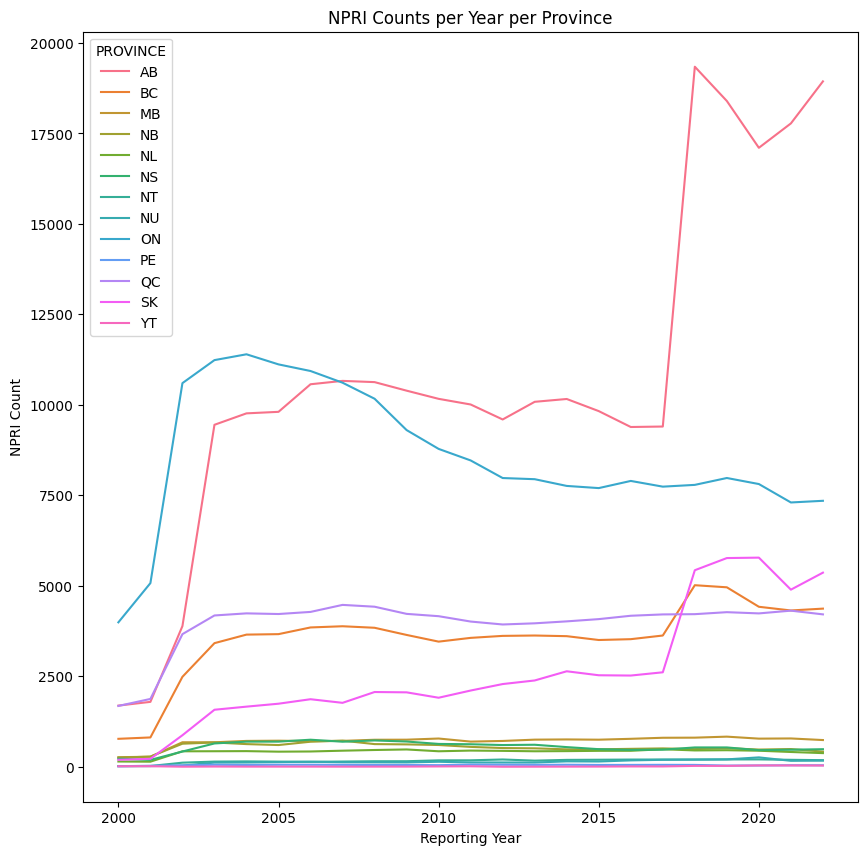

In [ ]:
# generate a line graph of npri counts per year per province
# log transform
plt.figure(figsize=(10, 10))
plt.title('NPRI Counts per Province Over Time')
plt.xlabel('Reporting Year')
plt.ylabel('NPRI Count')
sns.lineplot(data=df_releases_release, x='Reporting_Year / Année', y='NPRI_Count', hue='PROVINCE')

In [ ]:
df_disposal.sample(5)

,Reporting_Year / Année,NPRI_ID / No_INRP,Number of employees,Company_Name / Dénomination_sociale_de_l'entreprise,Facility_Name / Installation,NAICS / Code_SCIAN,NAICS Title / Titre Code_SCIAN,PROVINCE,City,Latitude,Longitude,CAS_Number / No_CAS,Substance Name (English) / Nom de substance (Anglais),Units / Unités,Estimation_Method / Méthode_d’estimation,Off-site Disposal - Land Treatment,Off-site Disposal - Landfill,Off-site Disposal - Storage,Off-site Disposal - Tailings Management,Off-site Disposal - Underground Injection,Off-site Disposal - Waste Rock management,Off-site Transfers for Recycling - Energy Recovery,Off-site Transfers for Recycling - Other,Off-site Transfers for Recycling - Recovery of Acids and Bases,Off-site Transfers for Recycling - Recovery of Catalysts,Off-site Transfers for Recycling - Recovery of Inorganic Materials (not metals),Off-site Transfers for Recycling - Recovery of Metals and Metal Compounds,Off-site Transfers for Recycling - Recovery of Organic Substances (not solvents),Off-site Transfers for Recycling - Recovery of Pollution Abatement Residues,Off-site Transfers for Recycling - Recovery of Solvents,Off-site Transfers for Recycling - Refining or Re-use of Used Oil,Off-site Transfers for Treatment Prior to Final Disposal - Biological Treatment,Off-site Transfers for Treatment Prior to Final Disposal - Chemical Treatment,Off-site Transfers for Treatment Prior to Final Disposal - Incineration / Thermal,Off-site Transfers for Treatment Prior to Final Disposal - Municipal Sewage Treatment Plant,Off-site Transfers for Treatment Prior to Final Disposal - Physical Treatment,On-site Disposal - Land Treatment,On-site Disposal - Landfill,On-site Disposal - Tailings Management,On-site Disposal - Underground Injection,On-site Disposal - Waste Rock management
40993,2005,3707,568,Imperial Oil,Strathcona Refinery,324110,Petroleum refineries,AB,Edmonton,53.54170,-113.3917,872-50-4,N-Methyl-2-pyrrolidone,tonnes,E1 - Site Specific Emission Factors,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.479,NaN
14715,2002,2595,450,TORAL CAST,TORAL CAST LIGHT METAL TECHNOLOGIES,336390,Other motor vehicle parts manufacturing,ON,CONCORD,43.82370,-79.4947,NA - 14,Zinc (and its compounds),tonnes,O - Engineering Estimates,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66062,2008,2230,3743,Suncor Energy Oil Sands Limited Partnership,Suncor Energy Inc. Oil Sands,211114,Non-conventional oil extraction,AB,Fort McMurray,57.00330,-111.4661,108-95-2,Phenol (and its salts),tonnes,E1 - Site Specific Emission Factors,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,230.7261,NaN,NaN
140860,2017,1931,48,Sherwin-Williams Canada,Fort Erie Plant,325510,Paint and coating manufacturing,ON,Fort Erie,42.91750,-78.9306,108-10-1,Methyl isobutyl ketone,tonnes,O - Engineering Estimates,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.485,NaN,0.0,NaN,0.075,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023,2000,2521,1200,Polycon Industries,(blank),326193,Motor vehicle plastic parts manufacturing,ON,Guelph,43.53191,-80.3110,67-63-0,Isopropyl alcohol,tonnes,O - Engineering Estimates,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.640,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_disposal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191645 entries, 0 to 191644
Data columns (total 41 columns):
 #   Column                                                                                       Non-Null Count   Dtype  
---  ------                                                                                       --------------   -----  
 0   Reporting_Year / Année                                                                       191645 non-null  int64  
 1   NPRI_ID / No_INRP                                                                            191645 non-null  int64  
 2   Number of employees                                                                          191551 non-null  object 
 3   Company_Name / Dénomination_sociale_de_l'entreprise                                          191645 non-null  object 
 4   Facility_Name / Installation                                                                 191019 non-null  object 
 5   NAICS / Code_SCIAN     

In [ ]:
df_comments.sample(5)

,Reporting_Year / Année,NPRI_ID / No_INRP,Company_Name / Dénomination_sociale_de_l'entreprise,Facility_Name / Installation,NAICS / Code_SCIAN,NAICS Title EN / Titre Code SCIAN EN,NAICS Title FR / Titre Code SCIAN FR,PROVINCE,CAS_Number / No_CAS,Substance Name (English) / Nom de substance (Anglais),Substance Name (French) / Nom de substance (Français),Comment_Type_Name (English) Type_de_commentaire (Anglais),Comment_Type_Name (French) Type_de_commentaire (Français),Comment / Commentaires
241175,2010,6420,Groupe Lebel (2004) Inc.,Groupe Lebel(2004) Inc.,321111,Sawmills (except Shingle and Shake Mills),Scieries (sauf les usines de bardeaux et de ba...,QC,NA - M10,PM2.5 - Particulate Matter <= 2.5 Micrometers,"PM2,5 - Matière particulaire <= 2,5 micromètres",On-site releases comment,Commentaire sur les rejets sur le site,Meilleure gestion de l'énergie
4768,2022,3899,Petro-Canada Lubricants Inc.,Mississauga Lubricants Centre,324190,Other petroleum and coal product manufacturing,Fabrication d'autres produits du pétrole et du...,ON,100-41-4,Ethylbenzene,Éthylbenzène,Disposal comment,Commentaire sur l'élimination,Increase in disposals due to sludge removal (b...
90405,2018,1439,Husky Oil Operations Limited,Rainbow Lake Gas plant,211110,Oil and gas extraction (except oil sands),Extraction de pétrole et de gaz (à l'exception...,AB,NA - M08,Total particulate matter,Matière particulaire totale,On-site releases comment,Commentaire sur les rejets sur le site,A round trip assumed for vehicles on unpaved r...
176250,2014,4559,GP North Woods LP,Englehart Oriented Strand Board Plant,321217,Waferboard mills,Usines de panneaux de copeaux,ON,9016-87-9,Polymeric diphenylmethane diisocyanate,Diisocyanate de diphénylméthane (polymérisé),Disposal comment,Commentaire sur l'élimination,no disposal
72134,2019,5125,NorthRiver Midstream Inc.,Jedney I Gas Plant,211110,Oil and gas extraction (except oil sands),Extraction de pétrole et de gaz (à l'exception...,BC,110-54-3,n-Hexane,n-Hexane,Recycling comment,Commentaire sur le recyclage,None sent for recycling


In [ ]:
df_comments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 363310 entries, 0 to 363309
Data columns (total 14 columns):
 #   Column                                                     Non-Null Count   Dtype 
---  ------                                                     --------------   ----- 
 0   Reporting_Year / Année                                     363310 non-null  int64 
 1   NPRI_ID / No_INRP                                          363310 non-null  int64 
 2   Company_Name / Dénomination_sociale_de_l'entreprise        363310 non-null  object
 3   Facility_Name / Installation                               359305 non-null  object
 4   NAICS / Code_SCIAN                                         363310 non-null  int64 
 5   NAICS Title EN / Titre Code SCIAN EN                       363294 non-null  object
 6   NAICS Title FR / Titre Code SCIAN FR                       363294 non-null  object
 7   PROVINCE                                                   363310 non-null  object
 8   CAS_

In [ ]:
 # create a new copy of the dataframe
df_new = df.copy()

In [ ]:
df_new.info(5)

<class 'pandas.core.frame.DataFrame'>
Index: 1292471 entries, 0 to 363309
Data columns (total 60 columns):
 #   Column                                                                                       Non-Null Count    Dtype  
---  ------                                                                                       --------------    -----  
 0   Reporting_Year / Année                                                                       1292471 non-null  int64  
 1   NPRI_ID / No_INRP                                                                            1292471 non-null  int64  
 2   Number of employees                                                                          928451 non-null   object 
 3   Company_Name / Dénomination_sociale_de_l'entreprise                                          1292471 non-null  object 
 4   Facility_Name / Installation                                                                 1286664 non-null  object 
 5   NAICS / Code_SCIAN  

If we look the data, you would see some (blank) in it which is not counted as missing value but just a random string called (blank), so we could fix the (blank) in fixing bad housekeeping

In [ ]:
# converting the 'Reporting Year' to datetime year
df_new['Reporting_Year / Année'] = pd.to_datetime(df_new['Reporting_Year / Année'], format='%Y')

In [ ]:
# show the datatypes
df_new.dtypes

,0
Reporting_Year / Année,datetime64[ns]
NPRI_ID / No_INRP,int64
Number of employees,object
Company_Name / Dénomination_sociale_de_l'entreprise,object
Facility_Name / Installation,object
NAICS / Code_SCIAN,int64
NAICS Title / Titre Code_SCIAN,object
PROVINCE,object
City,object
Latitude,float64


In [ ]:
# show the description (count values, unique values, mean etc) of the data
df_new.describe(include='all')

,Reporting_Year / Année,NPRI_ID / No_INRP,Number of employees,Company_Name / Dénomination_sociale_de_l'entreprise,Facility_Name / Installation,NAICS / Code_SCIAN,NAICS Title / Titre Code_SCIAN,PROVINCE,City,Latitude,...,On-site Disposal - Landfill,On-site Disposal - Tailings Management,On-site Disposal - Underground Injection,On-site Disposal - Waste Rock management,NAICS Title EN / Titre Code SCIAN EN,NAICS Title FR / Titre Code SCIAN FR,Substance Name (French) / Nom de substance (Français),Comment_Type_Name (English) Type_de_commentaire (Anglais),Comment_Type_Name (French) Type_de_commentaire (Français),Comment / Commentaires
count,1.292471e+06,1.292471e+06,928451.0,1292471,1286664,1.292471e+06,929161,1292471,834658.0,923908.000000,...,1.827000e+04,1.607200e+04,9329.000000,4.382000e+03,363294,363294,363310,363310,363310,358956
unique,NaN,NaN,1910.0,12387,37160,NaN,475,13,4083.0,NaN,...,NaN,NaN,NaN,NaN,678,416,250,8,8,150696
top,NaN,NaN,1.0,Canadian Natural Resources Limited,(blank),NaN,Conventional oil and gas extraction,AB,0.0,NaN,...,NaN,NaN,NaN,NaN,Conventional Oil and Gas Extraction,Extraction de pétrole et de gaz par des méthod...,"PM2,5 - Matière particulaire <= 2,5 micromètres",On-site releases comment,Commentaire sur les rejets sur le site,"Due to the system used at Univar Canada, the w..."
freq,NaN,NaN,168820.0,36540,15787,NaN,129865,389929,52756.0,NaN,...,NaN,NaN,NaN,NaN,27054,39328,24336,198782,198782,1413
mean,2.012339e+03,9.950304e+03,NaN,NaN,NaN,3.002099e+05,NaN,NaN,NaN,49.267241,...,5.675094e+03,4.849996e+04,718.124258,5.003218e+04,NaN,NaN,NaN,NaN,NaN,NaN
std,6.355565e+00,8.948623e+03,NaN,NaN,NaN,1.010390e+05,NaN,NaN,NaN,5.167066,...,9.407044e+04,4.978004e+05,7676.051457,6.067938e+05,NaN,NaN,NaN,NaN,NaN,NaN
min,2.000000e+03,1.000000e+00,NaN,NaN,NaN,1.111200e+05,NaN,NaN,NaN,0.000000,...,0.000000e+00,-2.607680e+02,0.000000,-2.220700e+05,NaN,NaN,NaN,NaN,NaN,NaN
25%,2.007000e+03,3.356000e+03,NaN,NaN,NaN,2.111140e+05,NaN,NaN,NaN,45.049300,...,1.709250e-01,4.364775e+01,0.126000,7.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN
50%,2.013000e+03,6.150000e+03,NaN,NaN,NaN,3.221120e+05,NaN,NaN,NaN,49.289200,...,7.900500e+00,2.893615e+02,2.560500,1.022652e+02,NaN,NaN,NaN,NaN,NaN,NaN
75%,2.018000e+03,1.645000e+04,NaN,NaN,NaN,3.312210e+05,NaN,NaN,NaN,53.288500,...,6.277875e+01,2.800930e+03,26.604000,1.958087e+03,NaN,NaN,NaN,NaN,NaN,NaN


#**Fixing** Bad Housekeeping

In [ ]:
blanks = ['(blank)'] # define the string (blank)

dictionary = {} # create an empty dictionary to collect the (blank) later on
for column in df_new.columns: # looping through each column
    dictionary[column] = df_new[column].astype(str).isin(blanks).sum() # convert columns to string to collect all the columns containing (blank) and get the counts of each

dictionary = pd.Series(dictionary) # converts summary to pd.Series to be able to filter it better
dictionary[dictionary > 0] # shows columns containing (blank)

,0
Number of employees,177
Facility_Name / Installation,15787
Estimation_Method / Méthode_d’estimation,6493


In [ ]:
import numpy as np # importing numpy
df_new['Facility_Name / Installation'] = df_new['Facility_Name / Installation'].replace('(blank)', np.nan) # converting the blank to an actual missing value

In [ ]:
df_new['Facility_Name / Installation'].isna().mean()*100

np.float64(1.670753154229379)

Applying the same method to the columns containing (blank)

In [ ]:
df_new['Estimation_Method / Méthode_d’estimation'] = df['Estimation_Method / Méthode_d’estimation'].replace('(blank)', np.nan)

In [ ]:
df_new['Estimation_Method / Méthode_d’estimation'].isna().mean()*100

np.float64(28.10972161077502)

In [ ]:
df_new['Number of employees'] = df['Number of employees'].replace('(blank)', np.nan)

/tmp/ipython-input-995237861.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_new['Number of employees'] = df['Number of employees'].replace('(blank)', np.nan)


In [ ]:
df_new['Number of employees'].isna().mean()*100

np.float64(28.17834984305257)

In [ ]:
na = ['N/A', 'na', 'NA'] # strings such as N/A, na, NA were also seen in the excel file so we would address that as well

dictionary = {}
for column in df_new.columns:
    dictionary[column] = df_new[column].astype(str).str.strip().isin(na).sum()

dictionary = pd.Series(dictionary)
dictionary[dictionary > 0]

,0
City,4536
Comment / Commentaires,672


Do the same method for the columns with 'N/A', 'na', 'NA'

In [ ]:
df_new['City'] = df_new['City'].replace(['NA', 'na', 'N/A'], np.nan)

In [ ]:
df_new['City'].isna().mean()*100

np.float64(35.77248541746778)

In [ ]:
df_new['Comment / Commentaires'] = df_new['Comment / Commentaires'].replace(['NA', 'na', 'N/A'], np.nan)

In [ ]:
df_new['Comment / Commentaires'].isna().mean()*100

np.float64(72.27844957449723)

In [ ]:
disposals_and_releases = [column for column in df_new.columns if 'Disposal' in column or 'Release' in column]

for column in disposals_and_releases:
    negatives = (df[column] < 0).sum()
    if negatives > 0:
        print(column, "negative values:", negatives)

On-site Disposal - Tailings Management negative values: 30
On-site Disposal - Waste Rock management negative values: 158


Handling Missing Values

In [ ]:
df_new.isnull().sum()

,0
Reporting_Year / Année,0
NPRI_ID / No_INRP,0
Number of employees,364197
Company_Name / Dénomination_sociale_de_l'entreprise,0
Facility_Name / Installation,21594
NAICS / Code_SCIAN,0
NAICS Title / Titre Code_SCIAN,363310
PROVINCE,0
City,462349
Latitude,368563


In [ ]:
df_new.isnull().mean()*100

,0
Reporting_Year / Année,0.000000
NPRI_ID / No_INRP,0.000000
Number of employees,28.178350
Company_Name / Dénomination_sociale_de_l'entreprise,0.000000
Facility_Name / Installation,1.670753
NAICS / Code_SCIAN,0.000000
NAICS Title / Titre Code_SCIAN,28.109722
PROVINCE,0.000000
City,35.772485
Latitude,28.516152


In [ ]:
median_val = df_new['Number of employees'].median()
df_new['Number of employees'] = df_new['Number of employees'].fillna(median_val)

In [ ]:
for column in ['City', 'Units / Unités', 'NAICS Title / Titre Code_SCIAN','Facility_Name / Installation','Latitude','Longitude','Estimation_Method / Méthode_d’estimation']:
  df_new[column] = df_new[column].fillna(df_new[column].mode().iloc[0])

In [ ]:
disposals_and_releases = [column for column in df_new.columns if ('Release' in column) or ('Disposal' in column) or ('Transfer' in column) or ('release' in column)]

for column in disposals_and_releases:
    df_new[column] = df_new[column].fillna(0)

In [ ]:
drop_cols = [
    'NAICS Title EN / Titre Code SCIAN EN',
    'NAICS Title FR / Titre Code SCIAN FR',
    'Substance Name (French) / Nom de substance (Français)',
    'Comment_Type_Name (English) Type_de_commentaire (Anglais)',
    'Comment_Type_Name (French) Type_de_commentaire (Français)',
    'Comment / Commentaires'
]

df_new = df_new.drop(columns=[c for c in drop_cols if c in df_new.columns])

In [ ]:
df_new.isnull().mean()*100

,0
Reporting_Year / Année,0.0
NPRI_ID / No_INRP,0.0
Number of employees,0.0
Company_Name / Dénomination_sociale_de_l'entreprise,0.0
Facility_Name / Installation,0.0
NAICS / Code_SCIAN,0.0
NAICS Title / Titre Code_SCIAN,0.0
PROVINCE,0.0
City,0.0
Latitude,0.0


#Outliers

In [ ]:
outlier_cols = [
    'Number of employees',
    'Release to Air - Fugitive',
    'Release to Air - Other Non-Point',
    'Release to Air - Road dust',
    'Release to Air - Spills',
    'Release to Air - Stack / Point',
    'Release to Air - Storage / Handling',
    'Releases to Land - Leaks',
    'Releases to Land - Other',
    'Releases to Land - Spills',
    'Releases to Water Bodies - Direct Discharges',
    'Releases to Water Bodies - Leaks',
    'Releases to Water Bodies - Spills',
    'Sum of release to all media (<1tonne)',
    'Off-site Disposal - Land Treatment',
    'Off-site Disposal - Landfill',
    'Off-site Disposal - Storage',
    'Off-site Disposal - Tailings Management',
    'Off-site Disposal - Underground Injection',
    'Off-site Disposal - Waste Rock management',
    'Off-site Transfers for Recycling - Energy Recovery',
    'Off-site Transfers for Recycling - Other',
    'Off-site Transfers for Recycling - Recovery of Acids and Bases',
    'Off-site Transfers for Recycling - Recovery of Catalysts',
    'Off-site Transfers for Recycling - Recovery of Inorganic Materials (not metals)',
    'Off-site Transfers for Recycling - Recovery of Metals and Metal Compounds',
    'Off-site Transfers for Recycling - Recovery of Organic Substances (not solvents)',
    'Off-site Transfers for Recycling - Recovery of Pollution Abatement Residues',
    'Off-site Transfers for Recycling - Recovery of Solvents',
    'Off-site Transfers for Recycling - Refining or Re-use of Used Oil',
    'Off-site Transfers for Treatment Prior to Final Disposal - Biological Treatment',
    'Off-site Transfers for Treatment Prior to Final Disposal - Chemical Treatment',
    'Off-site Transfers for Treatment Prior to Final Disposal - Incineration / Thermal',
    'Off-site Transfers for Treatment Prior to Final Disposal - Municipal Sewage Treatment Plant',
    'Off-site Transfers for Treatment Prior to Final Disposal - Physical Treatment',
    'On-site Disposal - Land Treatment',
    'On-site Disposal - Landfill',
    'On-site Disposal - Tailings Management',
    'On-site Disposal - Underground Injection',
    'On-site Disposal - Waste Rock management'
]


In [ ]:
outlier_cols = [c for c in df_new.columns
                if ('Release' in c) or ('Disposal' in c) or ('Transfer' in c)]
outlier_cols.insert(0, 'Number of employees')

for c in outlier_cols:
    df_new[c] = pd.to_numeric(df_new[c], errors='coerce')

    q1 = df_new[c].quantile(0.25)
    q3 = df_new[c].quantile(0.75)
    iqr = q3 - q1
    low = max(0, q1 - 1.5 * iqr)
    high = q3 + 1.5 * iqr
    before_outliers = ((df_new[c] < low) | (df_new[c] > high)).sum()

    df_new[c] = df_new[c].clip(lower=low, upper=high)

    after_outliers = ((df_new[c] < low) | (df_new[c] > high)).sum()

    print(f"\nColumn: {c}")
    print("   Outliers BEFORE:", before_outliers)
    print("   Outliers AFTER :", after_outliers)



Column: Number of employees
   Outliers BEFORE: 191838
   Outliers AFTER : 0

Column: Release to Air - Fugitive
   Outliers BEFORE: 116540
   Outliers AFTER : 0

Column: Release to Air - Other Non-Point 
   Outliers BEFORE: 27128
   Outliers AFTER : 0

Column: Release to Air - Road dust  
   Outliers BEFORE: 28669
   Outliers AFTER : 0

Column: Release to Air - Spills 
   Outliers BEFORE: 4862
   Outliers AFTER : 0

Column: Release to Air - Stack / Point  
   Outliers BEFORE: 273791
   Outliers AFTER : 0

Column: Release to Air - Storage / Handling 
   Outliers BEFORE: 71316
   Outliers AFTER : 0

Column: Releases to Land - Leaks
   Outliers BEFORE: 164
   Outliers AFTER : 0

Column: Releases to Land - Other 
   Outliers BEFORE: 4391
   Outliers AFTER : 0

Column: Releases to Land - Spills 
   Outliers BEFORE: 3007
   Outliers AFTER : 0

Column: Releases to Water Bodies - Direct Discharges 
   Outliers BEFORE: 49582
   Outliers AFTER : 0

Column: Releases to Water Bodies - Leaks
   Ou